# v4: DenseNet v3a — Temperature Scaling

**前提:** v3aの `results/models/v3a_val_predictions.npz` が存在すること。

**処理順序:**
1. val npzロード（logits + probs + labels）
2. Temperature Scaling（ECE計測 → T最適化）
3. T を `temperature_v3a.json` に保存

**出力先:** `results/v4_TS/`

**npzは一切書き換えない。** 下流ノートブック（v5, tsne等）はjsonからTを読んでその場でTS適用する。

**TSを先に行う理由:**
malignant 3クラスの確率をsumする集約では `sum(softmax(z/T))` が
`sum(softmax(z))` の単調変換にならない。
TS後に確率の相対順序が変わりうるため、閾値最適化の前にTSを適用する必要がある。


### ライブラリ読み込み・出力先設定

In [1]:
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import json as _json
from pathlib import Path
from datetime import datetime

import torch
import torch.nn as nn
import torch.optim as optim

NB_NAME     = 'v3a'
RESULTS_DIR = Path('../results/v4_TS')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f'Results dir: {RESULTS_DIR.resolve()}')

CLASS_NAMES       = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
NUM_CLASSES       = len(CLASS_NAMES)
MEL_IDX           = CLASS_NAMES.index('mel')
MALIGNANT_INDICES = [CLASS_NAMES.index(c) for c in ['mel', 'bcc', 'akiec']]
BENIGN_INDICES    = [CLASS_NAMES.index(c) for c in ['nv', 'bkl', 'df', 'vasc']]


Results dir: /home/komai/skin-lesion-triage/results/v4_TS


## 1. val predictions ロード

In [2]:
NPZ_PATH = Path('../results/models/v3a_val_predictions.npz')
_data         = np.load(NPZ_PATH)
all_probs_raw = _data['all_probs']   # (N, 7) TS前の生probs
all_logits_np = _data['all_logits']  # (N, 7) TS最適化の入力
y_true        = _data['y_true']      # (N,)
y_true_onehot = np.eye(NUM_CLASSES)[y_true]
N             = len(y_true)

print(f'Loaded: {NPZ_PATH}')
print(f'Val samples: {N}')
print(f'Class dist:  {dict(zip(CLASS_NAMES, np.bincount(y_true, minlength=NUM_CLASSES)))}')


Loaded: ../results/models/v3a_val_predictions.npz
Val samples: 551
Class dist:  {'akiec': np.int64(15), 'bcc': np.int64(17), 'bkl': np.int64(44), 'df': np.int64(4), 'mel': np.int64(23), 'nv': np.int64(441), 'vasc': np.int64(7)}


## 2. Temperature Scaling

**TSを先に行う理由:**
malignant 3クラスの確率をsumする集約では `sum(softmax(z/T))` が
`sum(softmax(z))` の単調変換にならない。
TS後に確率の相対順序が変わりうるため、閾値最適化の前にTSを適用する必要がある。


In [3]:
# ============================================================
# D. Model Calibration — 関数定義
# ============================================================
# Cell 1 の all_logits_np, all_probs, y_true を使用

import torch
import torch.nn as nn
import torch.optim as optim
import json

# --- ECE計算 ---
def compute_ece(probs, labels, n_bins=15):
    """
    ECE = 「モデルの表示値」と「実際の的中率」のズレの加重平均。
    
    血圧計の例:
      全確率帯（0-10%, 10-20%, ..., 90-100%）で
      「表示値の平均」と「実際に当たった割合」を比較。
      ズレが大きいほどECEが大きい = 血圧計が狂ってる。
    """
    confidences = np.max(probs, axis=1)       # 各画像の「一番高い確率」
    predictions = np.argmax(probs, axis=1)     # モデルの予測クラス
    accuracies  = (predictions == labels).astype(float)  # 当たったか

    bin_edges  = np.linspace(0.0, 1.0, n_bins + 1)
    bin_accs   = np.zeros(n_bins)
    bin_confs  = np.zeros(n_bins)
    bin_counts = np.zeros(n_bins, dtype=int)

    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        mask = (confidences >= lo) & (confidences <= hi if i == n_bins - 1 else confidences < hi)
        bin_counts[i] = mask.sum()
        if bin_counts[i] > 0:
            bin_accs[i]  = accuracies[mask].mean()
            bin_confs[i] = confidences[mask].mean()

    ece = np.sum(bin_counts / len(labels) * np.abs(bin_accs - bin_confs))
    return ece, {'bin_edges': bin_edges, 'bin_accs': bin_accs,
                 'bin_confs': bin_confs, 'bin_counts': bin_counts}


def compute_classwise_ece(probs, labels, class_idx, n_bins=15):
    """特定クラス（例: mel）だけの校正を測る。"""
    class_probs = probs[:, class_idx]
    class_true  = (labels == class_idx).astype(float)

    bin_edges  = np.linspace(0.0, 1.0, n_bins + 1)
    bin_accs   = np.zeros(n_bins)
    bin_confs  = np.zeros(n_bins)
    bin_counts = np.zeros(n_bins, dtype=int)

    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        mask = (class_probs >= lo) & (class_probs <= hi if i == n_bins - 1 else class_probs < hi)
        bin_counts[i] = mask.sum()
        if bin_counts[i] > 0:
            bin_accs[i]  = class_true[mask].mean()
            bin_confs[i] = class_probs[mask].mean()

    ece = np.sum(bin_counts / len(labels) * np.abs(bin_accs - bin_confs))
    return ece, {'bin_edges': bin_edges, 'bin_accs': bin_accs,
                 'bin_confs': bin_confs, 'bin_counts': bin_counts}


# --- Reliability Diagram ---
def plot_reliability_diagram(bin_data, ece, title='Reliability Diagram', save_path=None):
    """
    上段: 各確率帯での「表示値」vs「実測値」
          対角線（＝表示値と実測値が一致）に近いほど良い
          赤 = 表示値が実測より高い（高く出すぎ）
          緑 = 表示値が実測より低い（控えめすぎ）
    下段: 各確率帯に何枚の画像が入ったか
    """
    n_bins = len(bin_data['bin_accs'])
    centers = (bin_data['bin_edges'][:-1] + bin_data['bin_edges'][1:]) / 2
    w = bin_data['bin_edges'][1] - bin_data['bin_edges'][0]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8),
                                    gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

    ax1.bar(centers, bin_data['bin_accs'], width=w*0.85,
            color='#3498db', edgecolor='#2c3e50', alpha=0.85, label='Actual accuracy')
    for i in range(n_bins):
        if bin_data['bin_counts'][i] > 0:
            gap = bin_data['bin_confs'][i] - bin_data['bin_accs'][i]
            if abs(gap) > 0.01:
                color = '#e74c3c' if gap > 0 else '#2ecc71'
                ax1.bar(centers[i], abs(gap), width=w*0.85,
                        bottom=min(bin_data['bin_accs'][i], bin_data['bin_confs'][i]),
                        color=color, alpha=0.35)
    ax1.plot([0,1], [0,1], 'k--', lw=1.5, label='Perfect (display = actual)')
    ax1.set_ylabel('Actual accuracy', fontsize=13)
    ax1.set_title(f'{title}\nECE = {ece:.4f}', fontsize=14, fontweight='bold')
    ax1.legend(loc='upper left'); ax1.set_xlim(0,1); ax1.set_ylim(0,1)
    ax1.grid(True, alpha=0.3)

    ax2.bar(centers, bin_data['bin_counts'], width=w*0.85,
            color='#95a5a6', edgecolor='#2c3e50', linewidth=0.5)
    ax2.set_xlabel('Model output (displayed probability)', fontsize=13)
    ax2.set_ylabel('Count', fontsize=13); ax2.set_xlim(0,1)
    ax2.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"  → Saved: {save_path}")
    plt.show()


# --- Temperature Scaling ---
def fit_temperature(logits_np, labels_np):
    """
    Temperature Scaling: logits を T で割って確率を補正。
    血圧計の補正係数を自動で見つけるようなもの。
    T > 1 → 表示値を下げる（高く出すぎを補正）
    T < 1 → 表示値を上げる
    """
    logits_t = torch.from_numpy(logits_np).float()
    labels_t = torch.from_numpy(labels_np).long()
    temperature = nn.Parameter(torch.ones(1))
    nll = nn.CrossEntropyLoss()
    optimizer = optim.LBFGS([temperature], lr=0.01, max_iter=1000)

    def closure():
        optimizer.zero_grad()
        loss = nll(logits_t / temperature, labels_t)
        loss.backward()
        return loss
    optimizer.step(closure)

    T = temperature.item()
    with torch.no_grad():
        nll_before = nll(logits_t, labels_t).item()
        nll_after  = nll(logits_t / temperature, labels_t).item()
    print(f"  T = {T:.4f}")
    print(f"  NLL: {nll_before:.4f} → {nll_after:.4f} (Δ={nll_after-nll_before:+.4f})")
    return T


def apply_temperature(logits_np, T):
    """補正後の確率を返す。"""
    scaled = torch.from_numpy(logits_np).float() / T
    return torch.softmax(scaled, dim=1).numpy()


print("Calibration functions defined ✓")

Calibration functions defined ✓


D. Model Calibration

── D-3: 補正前 ──
  ECE = 0.0316
  → Saved: ../results/v4_TS/fig_d3_reliability_before.png


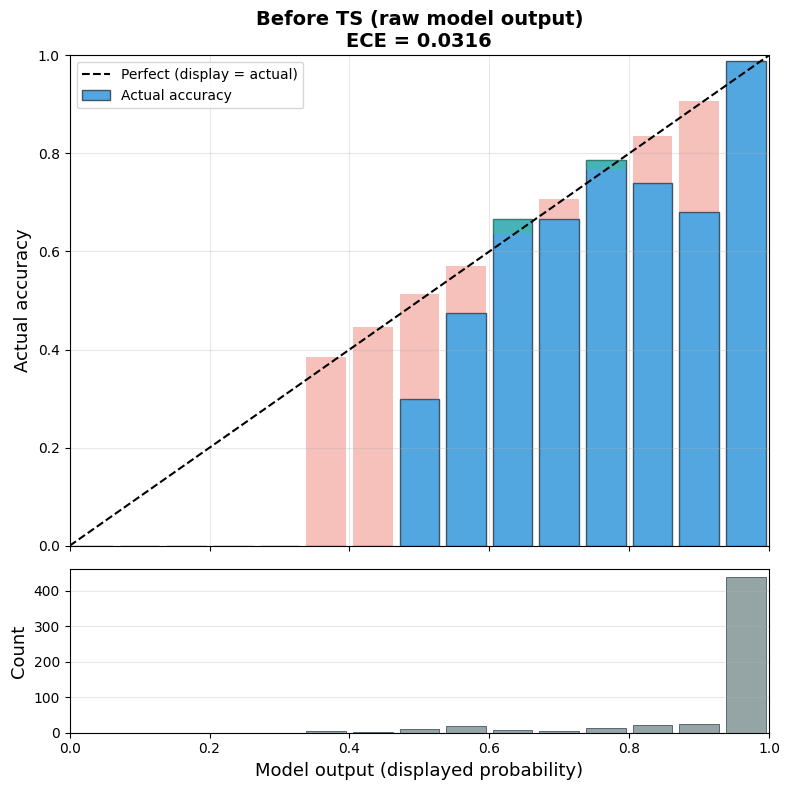


── D-4: Temperature Scaling ──
  T = 1.4478
  NLL: 0.2767 → 0.2539 (Δ=-0.0228)
  Saved: temperature_v3a.json

── D-5: 補正後 ──
  ECE: 0.0316 → 0.0289  (Δ=-0.0026)
  → Saved: ../results/v4_TS/fig_d5_reliability_after.png


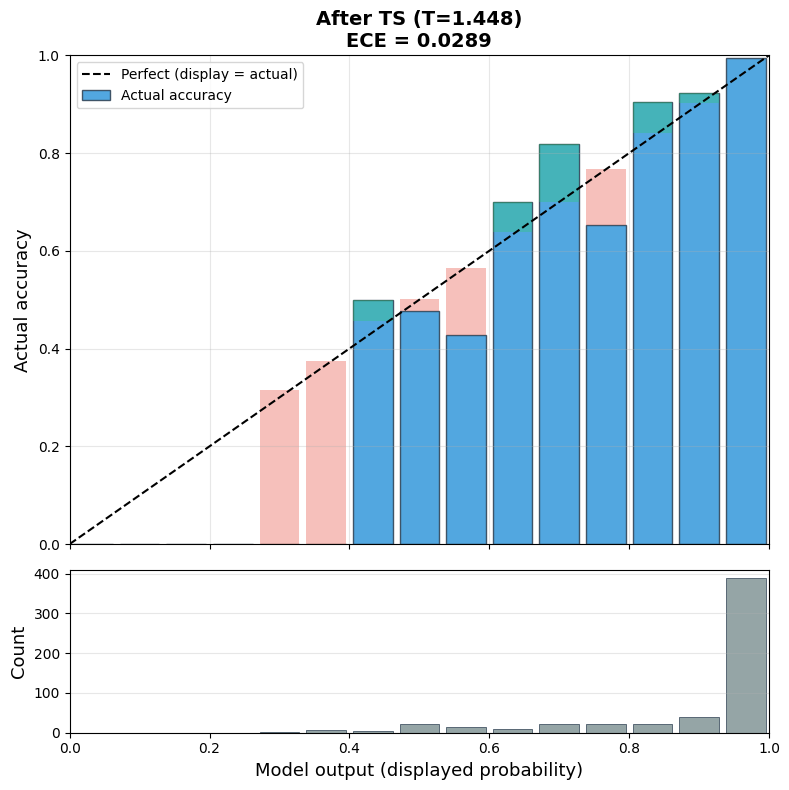

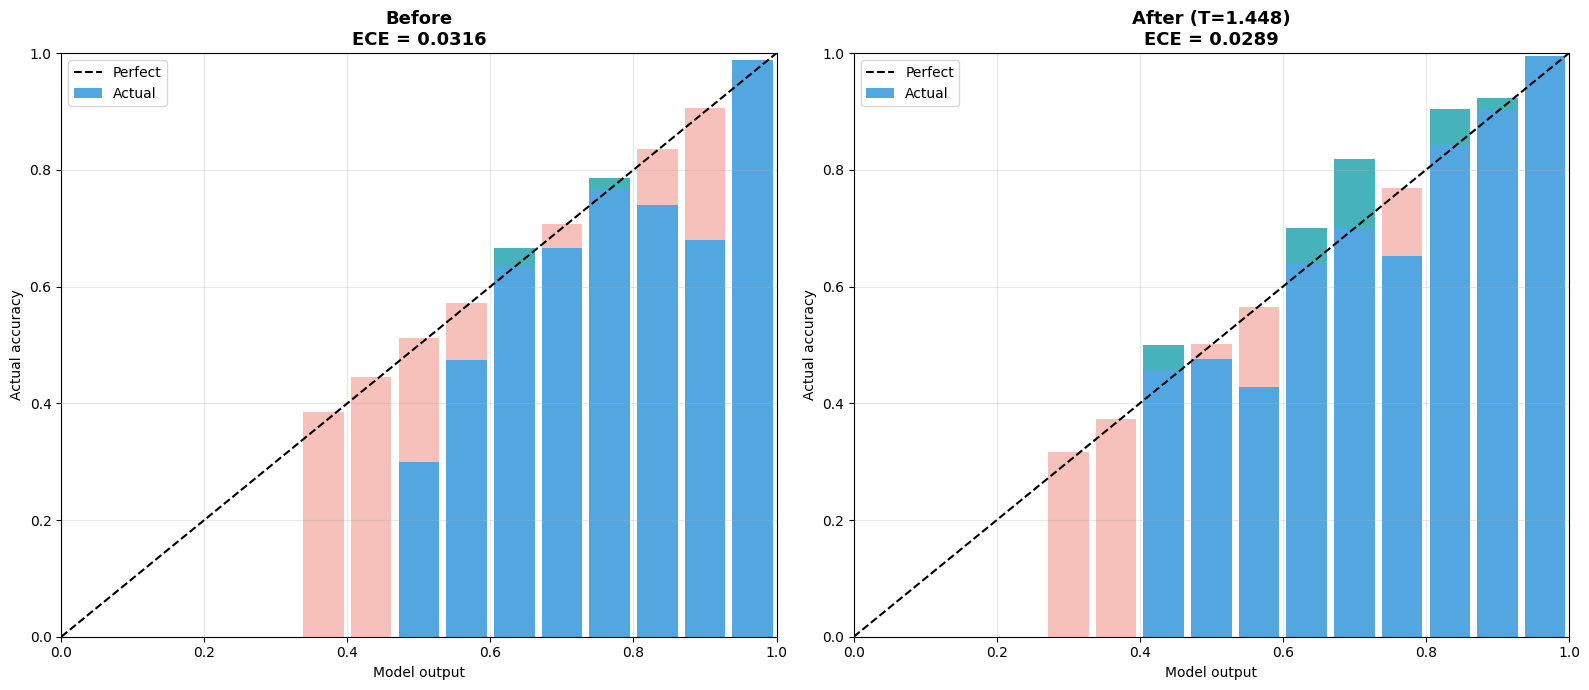


── D-6: mel単独 ──
  mel ECE: 0.0389 → 0.0331
  → Saved: ../results/v4_TS/fig_d6_reliability_mel_before.png


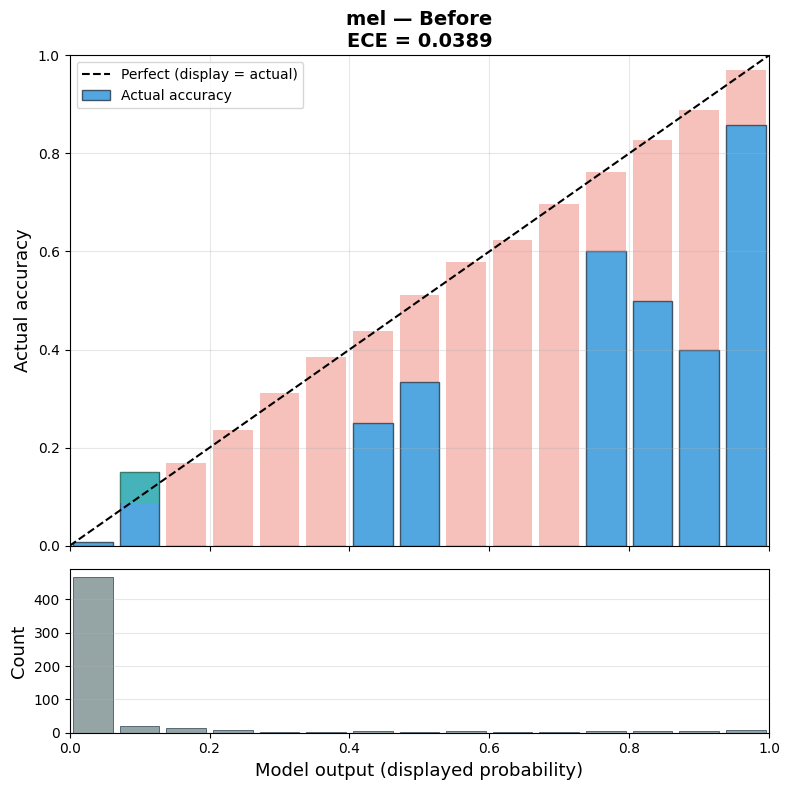

  → Saved: ../results/v4_TS/fig_d6_reliability_mel_after.png


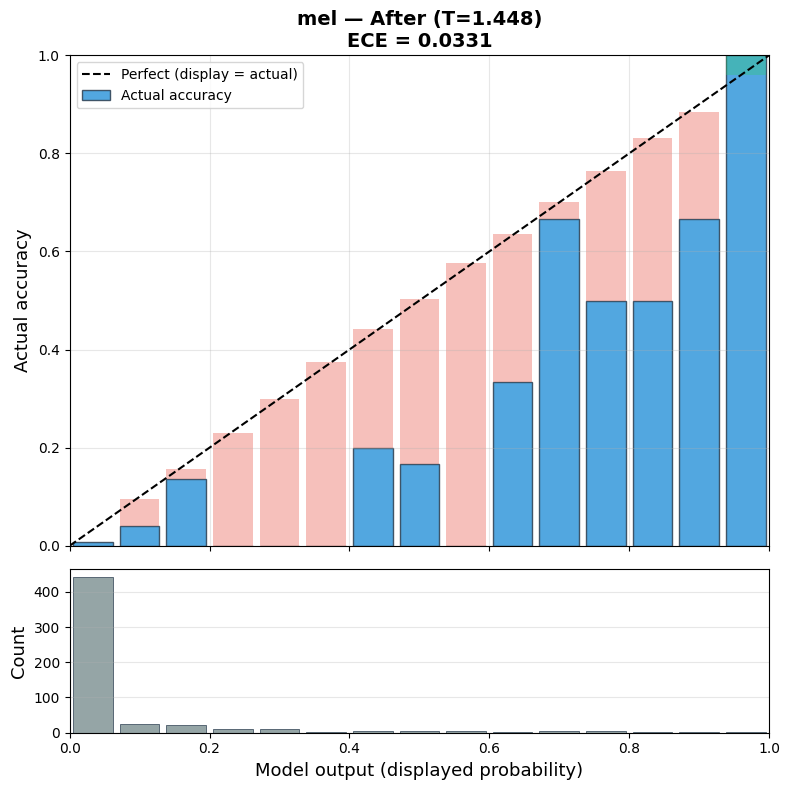


Class        Before      After          Δ
----------------------------------------
akiec        0.0166     0.0160    -0.0006
bcc          0.0106     0.0079    -0.0027
bkl          0.0184     0.0186    +0.0002
df           0.0061     0.0070    +0.0009
mel          0.0389     0.0331    -0.0058
nv           0.0343     0.0442    +0.0099
vasc         0.0023     0.0014    -0.0009
----------------------------------------
Overall      0.0316     0.0289    -0.0026

すべてのファイルを ../results/v4_TS に保存しました ✓


In [4]:
print('=' * 60)
print('D. Model Calibration')
print('=' * 60)

# ── D-3: 補正前 ──
print('\n── D-3: 補正前 ──')
ece_before, bd_before = compute_ece(all_probs_raw, y_true)
print(f'  ECE = {ece_before:.4f}')
plot_reliability_diagram(bd_before, ece_before,
    'Before TS (raw model output)',
    RESULTS_DIR / 'fig_d3_reliability_before.png')

# ── D-4: Temperature Scaling ──
print('\n── D-4: Temperature Scaling ──')
T = fit_temperature(all_logits_np, y_true)
probs_calibrated = apply_temperature(all_logits_np, T)

_json.dump(
    {'temperature': T, 'ece_before': float(ece_before), 'model': f'densenet_{NB_NAME}'},
    open(RESULTS_DIR / 'temperature_v3a.json', 'w'), indent=2
)
print(f'  Saved: temperature_v3a.json')

# ── D-5: 補正後 ──
print('\n── D-5: 補正後 ──')
ece_after, bd_after = compute_ece(probs_calibrated, y_true)
print(f'  ECE: {ece_before:.4f} → {ece_after:.4f}  (Δ={ece_after-ece_before:+.4f})')
plot_reliability_diagram(bd_after, ece_after,
    f'After TS (T={T:.3f})',
    RESULTS_DIR / 'fig_d5_reliability_after.png')

# Before/After 比較図
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, bd, ece, title in [
    (axes[0], bd_before, ece_before, 'Before'),
    (axes[1], bd_after,  ece_after,  f'After (T={T:.3f})'),
]:
    centers = (bd['bin_edges'][:-1] + bd['bin_edges'][1:]) / 2
    w = bd['bin_edges'][1] - bd['bin_edges'][0]
    ax.bar(centers, bd['bin_accs'], width=w*0.85, color='#3498db', alpha=0.85, label='Actual')
    ax.plot([0,1],[0,1],'k--', lw=1.5, label='Perfect')
    for i in range(len(bd['bin_accs'])):
        if bd['bin_counts'][i] > 0:
            gap = bd['bin_confs'][i] - bd['bin_accs'][i]
            if abs(gap) > 0.01:
                c = '#e74c3c' if gap > 0 else '#2ecc71'
                ax.bar(centers[i], abs(gap), width=w*0.85,
                       bottom=min(bd['bin_accs'][i], bd['bin_confs'][i]), color=c, alpha=0.35)
    ax.set_title(f'{title}\nECE = {ece:.4f}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Model output'); ax.set_ylabel('Actual accuracy')
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_d5_reliability_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── D-6: mel単独 ──
print('\n── D-6: mel単独 ──')
mel_ece_b, mel_bd_b = compute_classwise_ece(all_probs_raw, y_true, MEL_IDX)
mel_ece_a, mel_bd_a = compute_classwise_ece(probs_calibrated, y_true, MEL_IDX)
print(f'  mel ECE: {mel_ece_b:.4f} → {mel_ece_a:.4f}')
plot_reliability_diagram(mel_bd_b, mel_ece_b, 'mel — Before',
    RESULTS_DIR / 'fig_d6_reliability_mel_before.png')
plot_reliability_diagram(mel_bd_a, mel_ece_a, f'mel — After (T={T:.3f})',
    RESULTS_DIR / 'fig_d6_reliability_mel_after.png')

# 全クラス一覧
print(f"\n{'Class':<8} {'Before':>10} {'After':>10} {'Δ':>10}")
print('-' * 40)
for i, name in enumerate(CLASS_NAMES):
    b, _ = compute_classwise_ece(all_probs_raw, y_true, i)
    a, _ = compute_classwise_ece(probs_calibrated, y_true, i)
    print(f'{name:<8} {b:>10.4f} {a:>10.4f} {a-b:>+10.4f}')
print('-' * 40)
print(f"{'Overall':<8} {ece_before:>10.4f} {ece_after:>10.4f} {ece_after-ece_before:>+10.4f}")

# サマリー保存
_json.dump(
    {
        'temperature': T,
        'overall': {'ece_before': float(ece_before), 'ece_after': float(ece_after)},
        'melanoma': {'ece_before': float(mel_ece_b), 'ece_after': float(mel_ece_a)},
    },
    open(RESULTS_DIR / 'calibration_summary_v3a.json', 'w'), indent=2
)
print(f'\nすべてのファイルを {RESULTS_DIR} に保存しました ✓')


## 3. 実験ログ

In [5]:
# ============================================================
# 実験ログ出力（docs/04_実験ログ.md に追記）
# ============================================================
from datetime import datetime

# 全クラスECE一覧を再計算
class_ece_rows = ''
for idx, name in enumerate(CLASS_NAMES):
    b, _ = compute_classwise_ece(all_probs_raw, y_true, idx)
    a, _ = compute_classwise_ece(probs_calibrated, y_true, idx)
    class_ece_rows += f'| {name} | {b:.4f} | {a:.4f} | {a-b:+.4f} |\n'

lines = [
    '',
    '## v4: Temperature Scaling (DenseNet v3a)',
    f'- **日付**: {datetime.now().strftime("%Y-%m-%d")}',
    f'- **モデル**: densenet_v3a',
    f'- **入力**: results/models/v3a_val_predictions.npz',
    f'- **T**: {T:.4f}  (>1 = 過信傾向を補正)',
    '',
    '### ECE 全体',
    f'| | Before | After | Δ |',
    f'| --- | --- | --- | --- |',
    f'| Overall ECE | {ece_before:.4f} | {ece_after:.4f} | {ece_after-ece_before:+.4f} |',
    f'| mel ECE     | {mel_ece_b:.4f} | {mel_ece_a:.4f} | {mel_ece_a-mel_ece_b:+.4f} |',
    '',
    '### ECE クラス別',
    '| クラス | Before | After | Δ |',
    '| ------ | ------ | ----- | - |',
    class_ece_rows + f'| **Overall** | {ece_before:.4f} | {ece_after:.4f} | {ece_after-ece_before:+.4f} |',
    '',
    '### 成果物',
    f'- results/v4_TS/temperature_v3a.json       (T, ece_before)',
    f'- results/v4_TS/calibration_summary_v3a.json (overall + mel ECE before/after)',
    f'- results/v4_TS/fig_d3_reliability_before.png',
    f'- results/v4_TS/fig_d5_reliability_after.png',
    f'- results/v4_TS/fig_d5_reliability_comparison.png',
    f'- results/v4_TS/fig_d6_reliability_mel_before.png',
    f'- results/v4_TS/fig_d6_reliability_mel_after.png',
    '',
    '### 判断・メモ',
    '- TSはv5（post-hoc閾値最適化）の前に実施する必要がある',
    '- npzは書き換えない。下流はjsonからTを読みその場で適用',
    '  理由: malignant 3クラスsum集約はTSの単調変換性を破るため',
    '- mel ECEがTS後に微悪化する場合あり（全クラス共通Tによる副作用、既知挙動）',
    '',
]

print('\n'.join(lines))
print('\n↑ docs/04_実験ログ.md に追記してください')


## v4: Temperature Scaling (DenseNet v3a)
- **日付**: 2026-03-11
- **モデル**: densenet_v3a
- **入力**: results/models/v3a_val_predictions.npz
- **T**: 1.4478  (>1 = 過信傾向を補正)

### ECE 全体
| | Before | After | Δ |
| --- | --- | --- | --- |
| Overall ECE | 0.0316 | 0.0289 | -0.0026 |
| mel ECE     | 0.0389 | 0.0331 | -0.0058 |

### ECE クラス別
| クラス | Before | After | Δ |
| ------ | ------ | ----- | - |
| akiec | 0.0166 | 0.0160 | -0.0006 |
| bcc | 0.0106 | 0.0079 | -0.0027 |
| bkl | 0.0184 | 0.0186 | +0.0002 |
| df | 0.0061 | 0.0070 | +0.0009 |
| mel | 0.0389 | 0.0331 | -0.0058 |
| nv | 0.0343 | 0.0442 | +0.0099 |
| vasc | 0.0023 | 0.0014 | -0.0009 |
| **Overall** | 0.0316 | 0.0289 | -0.0026 |

### 成果物
- results/v4_TS/temperature_v3a.json       (T, ece_before)
- results/v4_TS/calibration_summary_v3a.json (overall + mel ECE before/after)
- results/v4_TS/fig_d3_reliability_before.png
- results/v4_TS/fig_d5_reliability_after.png
- results/v4_TS/fig_d5_reliability_comparison.png
- results/v4_TS/fig_d